---
# Initial Setup
1. Clone the repo
2. change directory
3. switch branches

In [1]:
!git clone https://github.com/Dewnan/NLP_Group_15.git
%cd NLP_Group_15
!git checkout feature/CIT-24-01-0020-model

Cloning into 'NLP_Group_15'...
remote: Enumerating objects: 275, done.
remote: Counting objects: 100% (99/99), done.
remote: Compressing objects: 100% (81/81), done.
remote: Total 275 (delta 40), reused 48 (delta 13), pack-reused 176 (from 1)
Receiving objects: 100% (275/275), 42.29 MiB | 22.85 MiB/s, done.
Resolving deltas: 100% (114/114), done.
/content/NLP_Group_15
Branch 'feature/CIT-24-01-0020-model' set up to track remote branch 'feature/CIT-24-01-0020-model' from 'origin'.
Switched to a new branch 'feature/CIT-24-01-0020-model'


---
**! Before Running the rest import the username and key from the Kaggle in to the colab secrets**
---

In [2]:
import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt
from src.data_downloader import download_dataset
from src.preprocess import load_and_merge, build_content_and_clean, apply_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [3]:
dataset_path = download_dataset()
print(f'Dataset downloaded to: {dataset_path}')

Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.
Dataset downloaded to: data


---
**Process the data set**

In [4]:
try:
    if os.path.exists('data/processed'):
        shutil.rmtree('data/processed')
    os.mkdir('data/processed')
except Exception as e:
    print(f'Failed to remove existing data sets / create a folder: {e}')

try:
    merged_df = load_and_merge()
    merged_df.to_csv('data/processed/merged_news.csv', index=False)
except Exception as e:
    print(f'Failed to merge data sets: {e}')

try:
    cleaned_df = build_content_and_clean(merged_df)
    cleaned_df.to_csv('data/processed/cleaned_news.csv', index=False)
except Exception as e:
    print(f'Failed to clean data sets: {e}')

try:
    tokenize_and_lemmatize_df = apply_tokenize(cleaned_df)
    tokenize_and_lemmatize_df.to_csv('data/processed/tokenized_news.csv', index=False)
except Exception as e:
    print(f'Failed to tokenize data sets: {e}')

# Exploratory Data Analysis

## Class distribution

Class Counts: 
label
0    21417
1    23481
Name: count, dtype: int64

Real data count: 21417, Percentage: 47.7%
Fake data count: 23481, Percentage: 52.3%


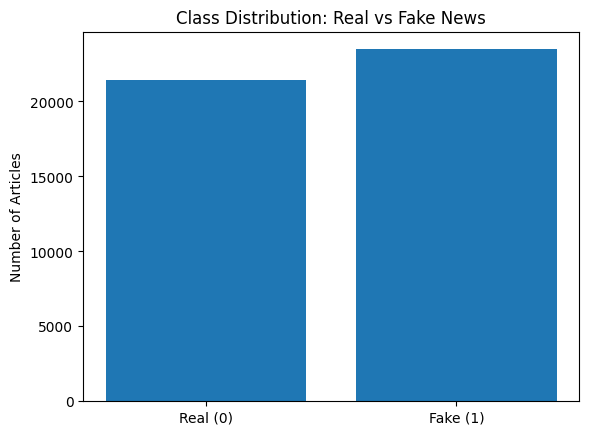

In [5]:
merged_df = pd.read_csv('data/processed/merged_news.csv')

class_counts = merged_df['label'].value_counts().sort_index()
print(f'Class Counts: \n{class_counts}\n')

real_count = class_counts[0]
fake_count = class_counts[1]
total = len(merged_df)

real_percent = real_count / total * 100
fake_percent = fake_count / total * 100

print(f"Real data count: {real_count}, Percentage: {real_percent:.1f}%")
print(f"Fake data count: {fake_count}, Percentage: {fake_percent:.1f}%")

plt.bar(['Real (0)', 'Fake (1)'], class_counts.values, width=0.8)
plt.title('Class Distribution: Real vs Fake News')
plt.ylabel('Number of Classes')
plt.ylabel('Number of Articles')
plt.show()

## Text Length Distribution

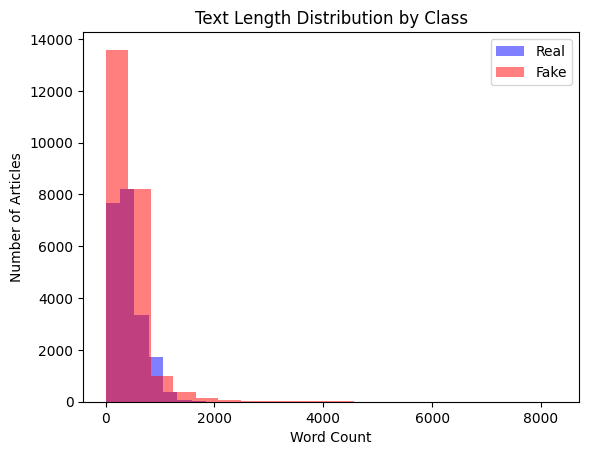

         count        mean         std  min    25%    50%    75%     max
label                                                                   
0      21417.0  398.550777  276.829950  4.0  158.0  371.0  537.0  5254.0
1      23481.0  440.708232  413.707991  1.0  256.0  379.0  523.0  8289.0


In [6]:
cleaned_df = pd.read_csv('data/processed/cleaned_news.csv')

def word_counter(text):
  words = str(text).split()
  return len(words)

cleaned_df['word_count'] = cleaned_df['content'].apply(word_counter)

real_article_Wcount = cleaned_df[cleaned_df['label'] == 0]['word_count']
fake_article_Wcount = cleaned_df[cleaned_df['label'] == 1]['word_count']

plt.hist(real_article_Wcount, bins=20, alpha=0.5, label='Real', color='blue')
plt.hist(fake_article_Wcount, bins=20, alpha=0.5, label='Fake', color='red')

plt.xlabel('Word Count')
plt.ylabel('Number of Articles')
plt.title('Text Length Distribution by Class')
plt.legend()
plt.show()

print(cleaned_df.groupby('label')['word_count'].describe())

In [7]:
cleaned_df.sort_values('word_count').head(10)[['label', 'word_count', 'content']]

,label,word_count,content
18825,1,1,NaN
32368,1,1,NaN
26511,1,1,NaN
13550,1,1,NaN
44358,1,1,NaN
22439,1,1,NaN
43173,1,1,NaN
18327,1,1,NaN
16730,1,1,NaN
24,1,3,LIVE FEED INAUGURATION
